In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from scripts.plotting import *

def make_s_curve(n_samples=100, noise=0.0, random_state=None):
    """Generate an S curve dataset.

    Parameters
    ----------
    n_samples : int, default=100
        The number of sample points on the S curve.

    noise : float, default=0.0
        The standard deviation of the gaussian noise.

    random_state : int, Generator instance, or None, default=None
        Determines random number generation for dataset creation. Pass an int
        for reproducible output across multiple function calls.

    Returns
    -------
    X : ndarray of shape (n_samples, 3)
        The points.

    t : ndarray of shape (n_samples,)
        The univariate position of the sample according
        to the main dimension of the points in the manifold.
    """
    # Create a Generator instance
    rng = np.random.default_rng(random_state)

    t = 3 * np.pi * (rng.uniform(size=n_samples) - 0.5)
    X = np.empty(shape=(n_samples, 3), dtype=np.float64)
    X[:, 0] = np.sin(t)
    X[:, 1] = 2.0 * rng.uniform(size=n_samples)
    X[:, 2] = np.sign(t) * (np.cos(t) - 1)
    X += noise * rng.standard_normal(size=(n_samples, 3))
    t = np.squeeze(t)
    return X, t


def compute_s_curve_derivative(t):
    """
    Compute the derivative of the S curve with respect to t.

    Parameters
    ----------
    t : ndarray
        The univariate position of the sample according to the main dimension
        of the points in the manifold.

    Returns
    -------
    dX_dt : ndarray of shape (n_samples, 3)
        The derivatives of the S curve with respect to t for each coordinate.
    """
    # Compute derivatives for each component
    dx0_dt = np.pi * np.cos(t)          # Derivative of sin(t) with respect to t
    dx1_dt = np.zeros_like(t)   # Constant component for y (2.0 * uniform), derivative is zero
    dx2_dt = -np.sin(t) * np.sign(t)  # Derivative of z component with respect to t

    dx0_dy = np.zeros_like(t)    # Constant component for y (2.0 * uniform), derivative is zero
    dx1_dy = 2 * np.ones_like(t)     # Constant component for y (2.0 * uniform), derivative is 1
    dx2_dy = np.zeros_like(t)    # Constant component for y (2.0 * uniform), derivative is zero
    
    # Combine into a single array
    dX_dt = np.stack([dx0_dt, dx1_dt, dx2_dt], axis=1)
    dX_dy = np.stack([dx0_dy, dx1_dy, dx2_dy], axis=1)
    
    return dX_dt, dX_dy


def compute_general_derivative(t, dt_ds):
    """
    Compute the derivative of the S curve with respect to a general parameter s,
    where t is a function of s.

    Parameters
    ----------
    t : ndarray
        The values of t for the S curve.

    dt_ds : ndarray
        The derivative of t with respect to s (dt/ds).

    Returns
    -------
    dX_ds : ndarray of shape (n_samples, 3)
        The derivative of the S curve with respect to s for each coordinate.
    """
    # Compute derivatives for each component with respect to t
    dx0_dt = np.cos(t)          # Derivative of sin(t) with respect to t
    dx1_dt = np.zeros_like(t)   # y-coordinate derivative is zero (constant in this case)
    dx2_dt = -np.sin(t) * np.sign(t)  # Derivative of z-component with respect to t

    # Stack derivatives to form dX/dt
    dX_dt = np.stack([dx0_dt, dx1_dt, dx2_dt], axis=1)

    # Apply chain rule to compute dX/ds
    dX_ds = dX_dt * dt_ds[:, np.newaxis]  # Multiply by dt/ds for each coordinate
    dY_ds = None
    return dX_ds, dY_ds

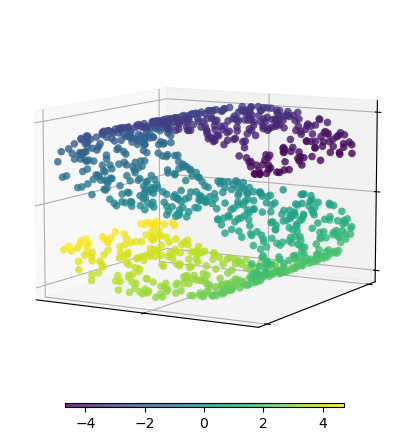

In [3]:
X, t = make_s_curve(1000, random_state=42)
plot_3d(X, t, "", dot_size=30, alpha=0.8)

In [4]:
def normalize_rows(dX_dt):
    # Compute the L2 norm for each row (with keepdims for proper broadcasting)
    row_norms = np.linalg.norm(dX_dt, axis=1, keepdims=True)
    
    # Avoid division by zero: if a row's norm is zero, set it to 1 (so the row stays unchanged)
    row_norms[row_norms == 0] = 1
    
    # Divide each element in the row by the corresponding row norm
    return dX_dt / row_norms

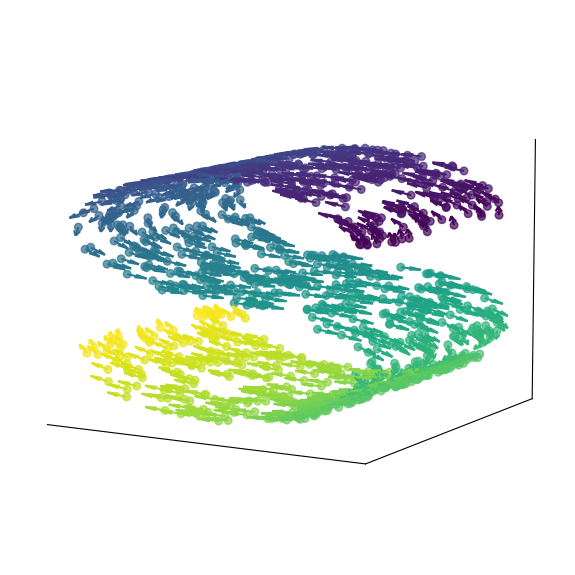

In [5]:
# Compute derivatives with respect to s
dX_dt, dX_dy = compute_s_curve_derivative(t)
dX_ds = normalize_rows(dX_dt)
plot_3d_with_quiver(X, dX_ds, t, s=30, alpha=0.7, 
                    arrow_size=0.15, normalize=False, 
                    title="", cmap="viridis", show_colorbar=False, show_axes=False)

In [6]:
# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
rng = np.random.default_rng(42)

# ------------------------------------------------------------------
# Noise levels (position std, velocity std)
# ------------------------------------------------------------------
noise_levels = {
    1:  {"pos": 0.25,  "vel": 0.3},
    2:    {"pos": 0.25,  "vel": 0.6},
    3: {"pos": 0.25,  "vel": 0.9},
    4:   {"pos": 0.25,  "vel": 1.2},
}

# ------------------------------------------------------------------
# Container for all simulations
# ------------------------------------------------------------------
noisy_simulations = {}

for level, stds in noise_levels.items():
    pos_std = stds["pos"]
    vel_std = stds["vel"]

    noisy_points = X + rng.normal(scale=pos_std, size=X.shape)
    noisy_dX_ds  = dX_ds + rng.normal(scale=vel_std, size=dX_ds.shape)

    noisy_simulations[level] = {
        "X_noisy": noisy_points,
        "V_noisy": noisy_dX_ds,
        "position_noise_std": pos_std,
        "velocity_noise_std": vel_std,
    }

# Inspect keys
noisy_simulations.keys()

dict_keys([1, 2, 3, 4])

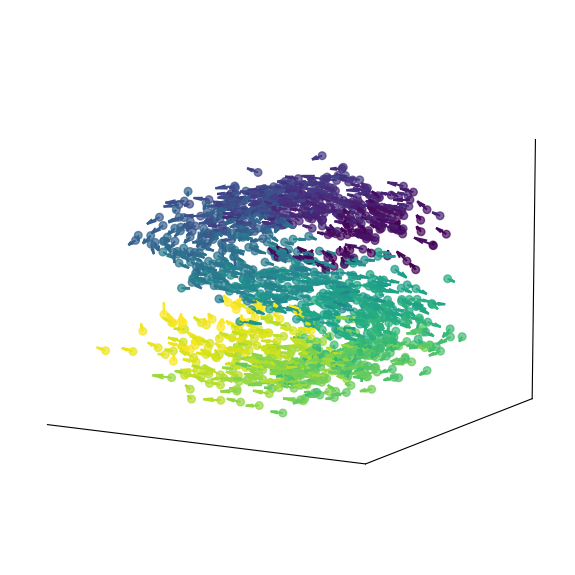

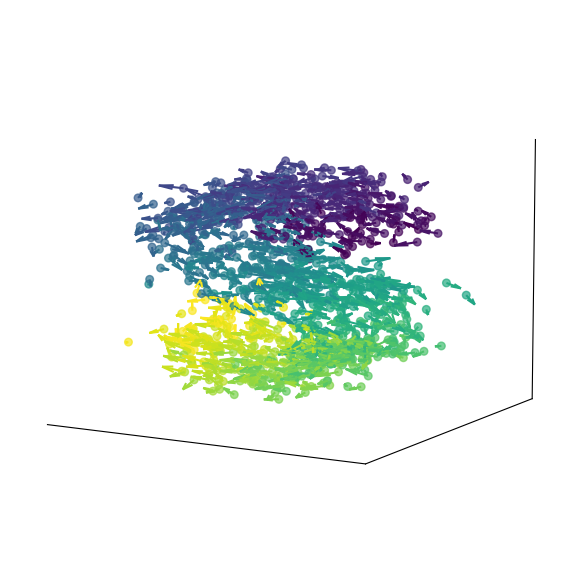

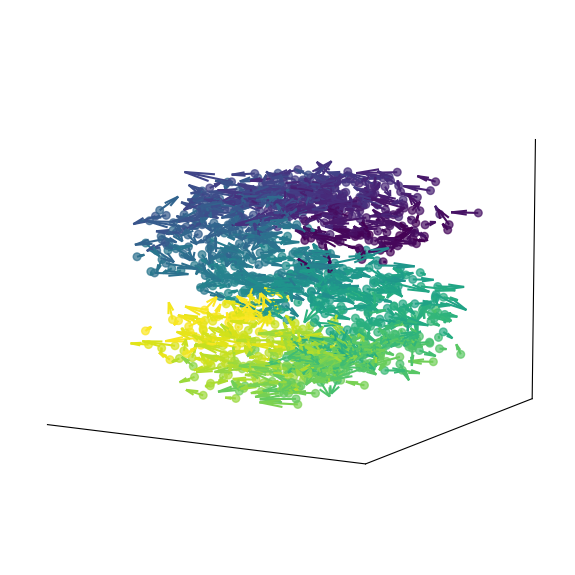

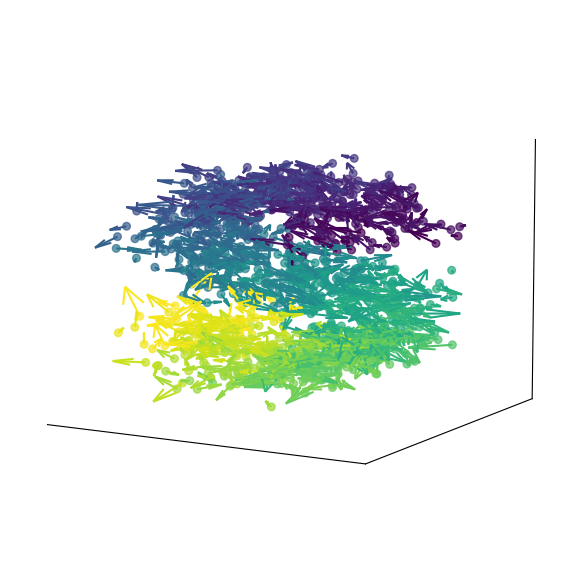

In [7]:
plot_3d_with_quiver(noisy_simulations[1]["X_noisy"], noisy_simulations[1]["V_noisy"], t, s=30, alpha=0.7, 
                    arrow_size=0.15, normalize=False, 
                    title="", cmap="viridis", show_colorbar=False, show_axes=False)

plot_3d_with_quiver(noisy_simulations[2]["X_noisy"], noisy_simulations[2]["V_noisy"], t, s=30, alpha=0.7, 
                    arrow_size=0.15, normalize=False, 
                    title="", cmap="viridis", show_colorbar=False, show_axes=False)

plot_3d_with_quiver(noisy_simulations[3]["X_noisy"], noisy_simulations[3]["V_noisy"], t, s=30, alpha=0.7, 
                    arrow_size=0.15, normalize=False, 
                    title="", cmap="viridis", show_colorbar=False, show_axes=False)

plot_3d_with_quiver(noisy_simulations[4]["X_noisy"], noisy_simulations[4]["V_noisy"], t, s=30, alpha=0.7, 
                    arrow_size=0.15, normalize=False, 
                    title="", cmap="viridis", show_colorbar=False, show_axes=False)

/Users/jh/micromamba/envs/scvelo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[PCA] Skipped (input dim = 3)
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


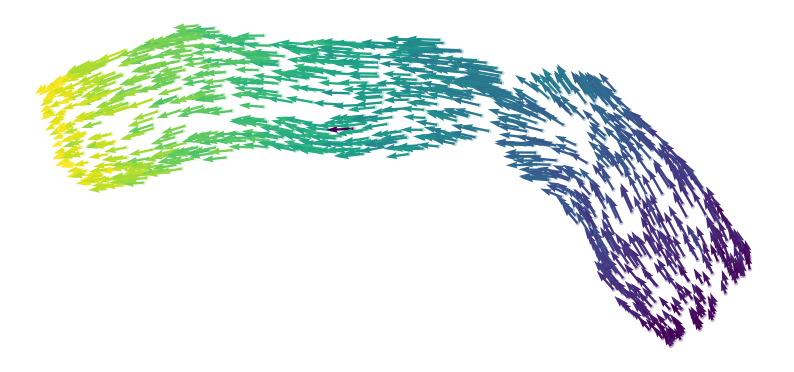

[PCA] Skipped (input dim = 3)
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


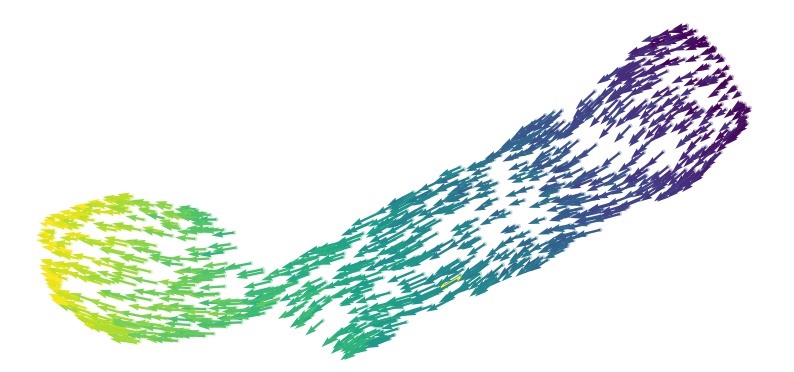

[PCA] Skipped (input dim = 3)
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


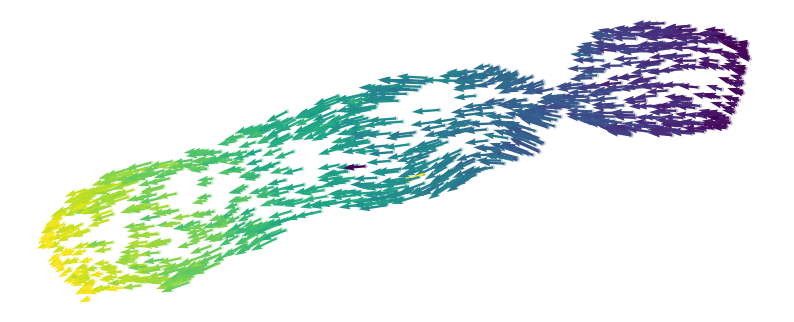

[PCA] Skipped (input dim = 3)
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


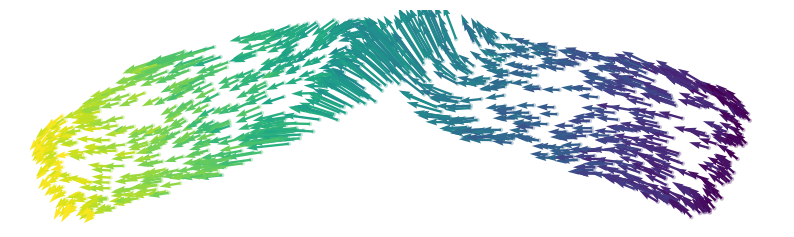

In [8]:
from scripts.VectorFieldEmbedder import *
from scripts.plotting import *
from scripts.TPS import *

for i in range(1,5):
    emb = VectorFieldEmbedder(noisy_simulations[i]["X_noisy"], noisy_simulations[i]["V_noisy"], dist_method="phase",
                              embed_kwargs={"n_neighbors":30,
                                             "min_dist":0.3},
                              dof=30,method="umap")
    emb.initialize_embedding(42)
    
    # plot_velocity_streamplot(
    #     X_2d=emb.X_emb,
    #     tps_vf=emb.tps_vf,
    #     scatter_color=t,
    #     grid_density=1.0, 
    #     stream_density=0.7,
    #     scatter_size=200,
    #     scatter_alpha=0.1,
    #     figsize=(5, 4),
    #     aspect=1,
    #     grid_size=50,
    #     show_axes=False,
    #     cmap="viridis"
    # )
    
    plot_2d_quiver(
        emb.X_emb,
        emb.V_emb,
        t,
        scale=3,
        cmap="viridis"
    )

Processing noise level: 1


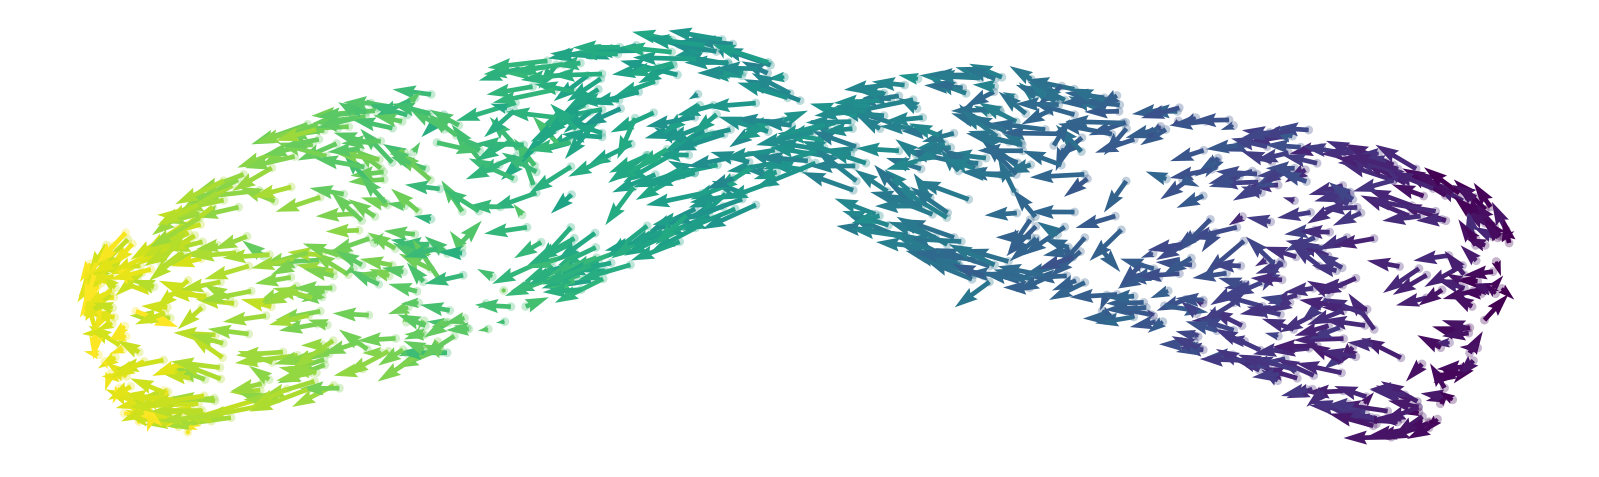

Processing noise level: 2


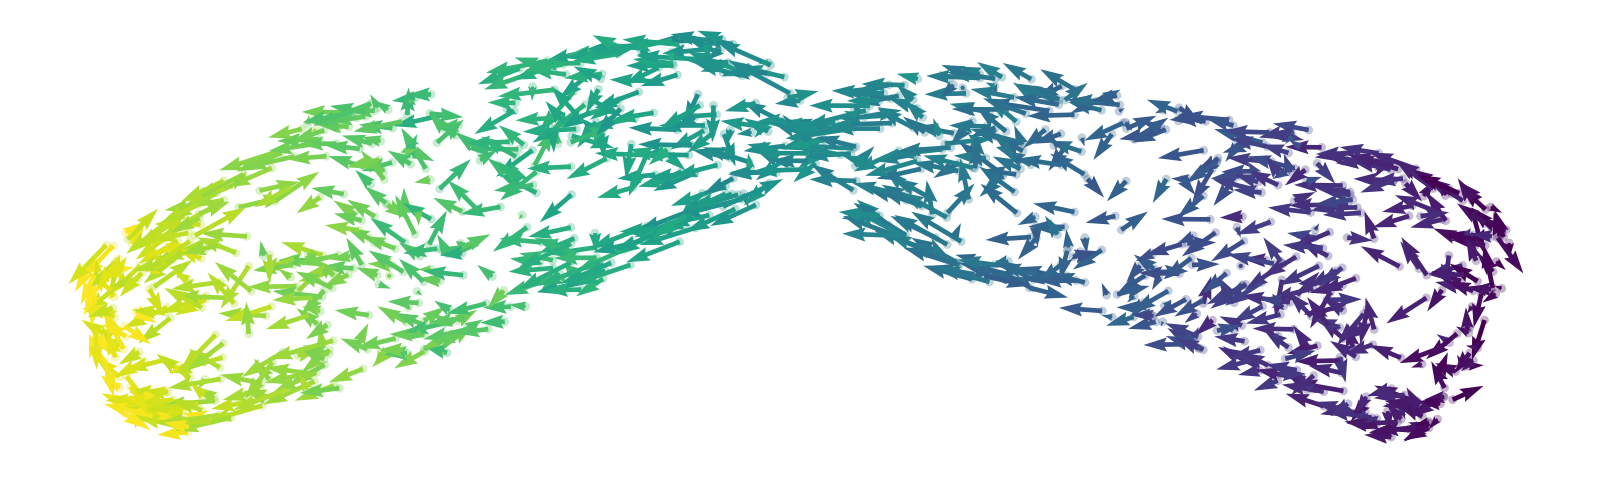

Processing noise level: 3


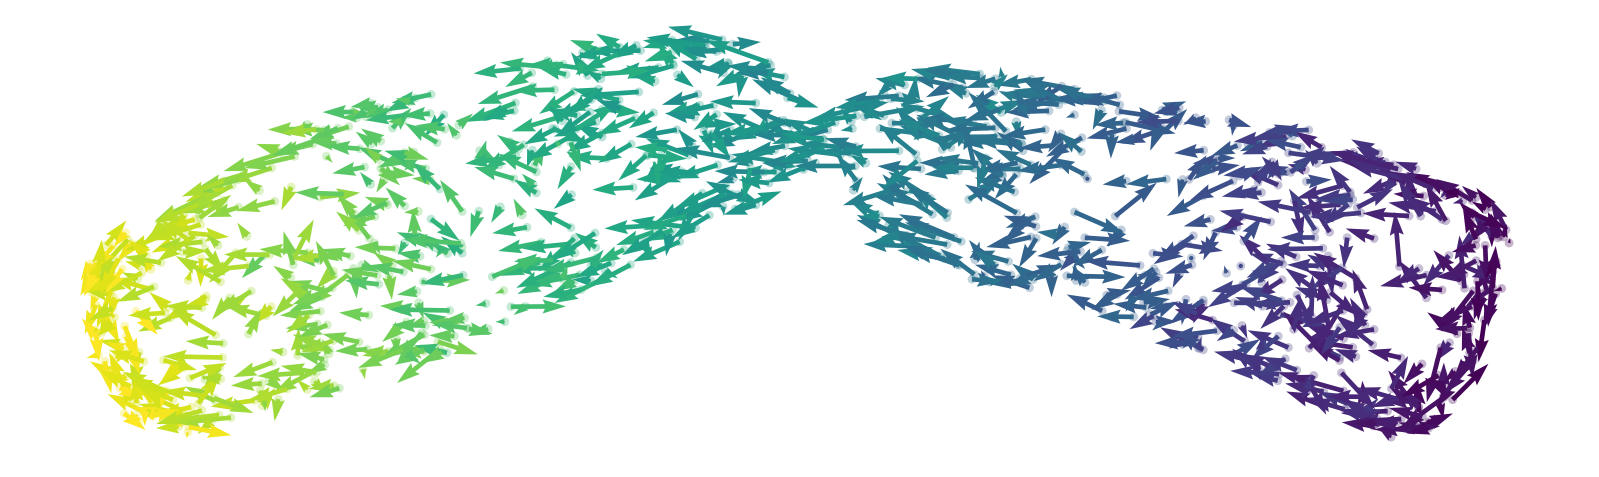

Processing noise level: 4


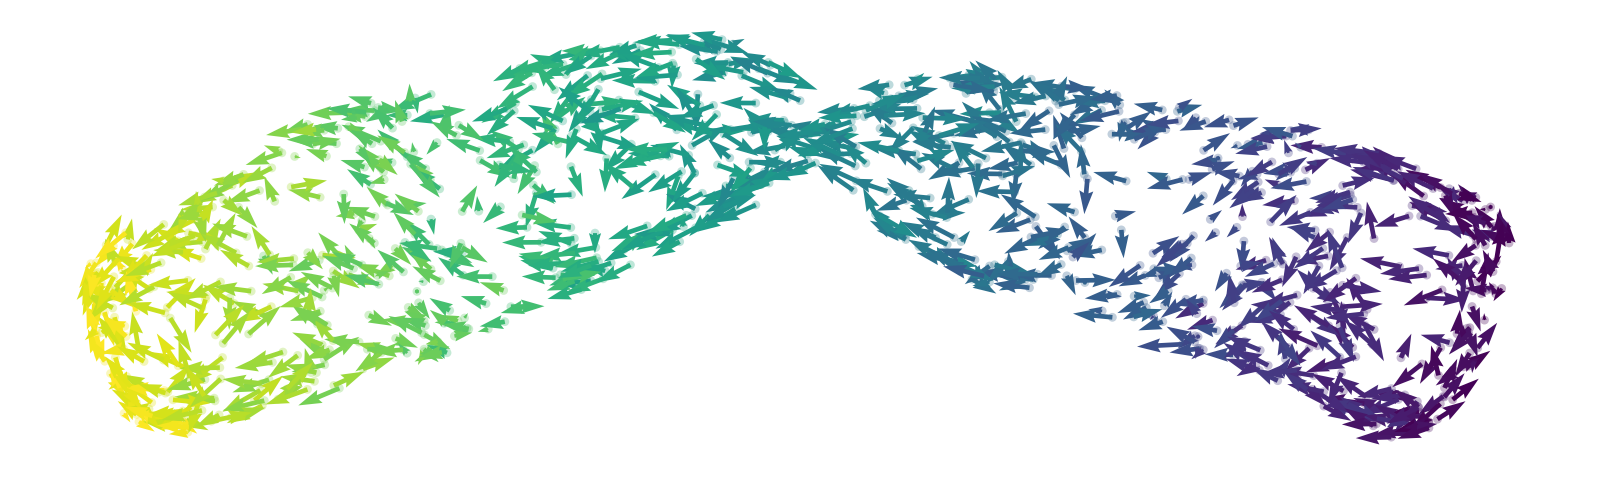

In [9]:
import anndata
import scvelo as scv
import scanpy as sc

scv.settings.verbosity = 0
scv.settings.set_figure_params(frameon=False)

X_emb = emb.X_emb  # fixed 2D embedding

for level, sim in noisy_simulations.items():
    print(f"Processing noise level: {level}")

    X = sim["X_noisy"]
    V = sim["V_noisy"]

    # -----------------------------
    # Build AnnData
    # -----------------------------
    adata = anndata.AnnData(X)
    adata.layers["position"] = X
    adata.layers["velocity"] = V
    adata.obs["color"] = t
    adata.obsm["X_umap"] = X_emb  # use embedding as-is

    # -----------------------------
    # scVelo: compute embedding velocities
    # -----------------------------
    scv.pp.neighbors(adata, n_neighbors=30, use_rep="X")
    scv.tl.velocity_graph(adata, xkey="position", vkey="velocity")
    scv.tl.velocity_embedding(adata, basis="umap")

    # -----------------------------
    # Extract scVelo embedding + velocity
    # -----------------------------
    X_plot = adata.obsm["X_umap"]
    V_plot = adata.obsm["velocity_umap"]

    # -----------------------------
    # Your plotting function
    # -----------------------------
    plot_2d_quiver(
        X_plot,
        V_plot,
        t,
        scale=0.2,
        cmap="viridis",
    )


In [10]:
# Define the dimensions for projection
high_dim = 100
np.random.seed(42)  # Ensure reproducibility

# Generate a random projection matrix
projection_matrix = np.random.normal(size=(3, high_dim))

# Project the clean data to 100 dimensions
high_dim_points = X @ projection_matrix  # Shape: (n_samples, high_dim)
high_dim_velocity = dX_ds @ projection_matrix  # Shape: (n_samples, high_dim)

# Add Gaussian noise to the high-dimensional data
high_dim_points_noisy = high_dim_points + np.random.normal(scale=3.5, size=high_dim_points.shape)
high_dim_velocity_noisy = high_dim_velocity + np.random.normal(scale=2.8, size=high_dim_velocity.shape)

# Define file names for high-dimensional noisy data
from pathlib import Path
outdir = Path("./data/s_curve/uniform")
outdir.mkdir(parents=True, exist_ok=True)

# Save base S-curve data used by downstream notebooks
gt_position_matrix_file = outdir / "s_curve_gt_position_matrix.csv"
gt_velocity_matrix_file = outdir / "s_curve_gt_velocity_matrix.csv"
gt_latent_time_vector_file = outdir / "s_curve_gt_latent_time_vector.csv"
noisy_position_matrix_file = outdir / "s_curve_noisy_position_matrix.csv"
noisy_velocity_matrix_file = outdir / "s_curve_noisy_velocity_matrix.csv"

pd.DataFrame(X).to_csv(gt_position_matrix_file, index=False, header=[f"dim_{i}" for i in range(X.shape[1])])
pd.DataFrame(dX_ds).to_csv(gt_velocity_matrix_file, index=False, header=[f"dim_{i}" for i in range(dX_ds.shape[1])])
pd.DataFrame({"t": t}).to_csv(gt_latent_time_vector_file, index=False)
pd.DataFrame(noisy_simulations[1]["X_noisy"]).to_csv(noisy_position_matrix_file, index=False, header=[f"dim_{i}" for i in range(X.shape[1])])
pd.DataFrame(noisy_simulations[1]["V_noisy"]).to_csv(noisy_velocity_matrix_file, index=False, header=[f"dim_{i}" for i in range(dX_ds.shape[1])])
noisy_hd_position_matrix_file = outdir / "s_curve_noisy_hd_position_matrix.csv"
noisy_hd_velocity_matrix_file = outdir / "s_curve_noisy_hd_velocity_matrix.csv"

# Save high-dimensional noisy data
pd.DataFrame(high_dim_points_noisy).to_csv(noisy_hd_position_matrix_file, index=False, header=[f"dim_{i}" for i in range(high_dim)])
pd.DataFrame(high_dim_velocity_noisy).to_csv(noisy_hd_velocity_matrix_file, index=False, header=[f"dim_{i}" for i in range(high_dim)])

(noisy_hd_position_matrix_file, noisy_hd_velocity_matrix_file)

(PosixPath('data/s_curve/uniform/s_curve_noisy_hd_position_matrix.csv'),
 PosixPath('data/s_curve/uniform/s_curve_noisy_hd_velocity_matrix.csv'))

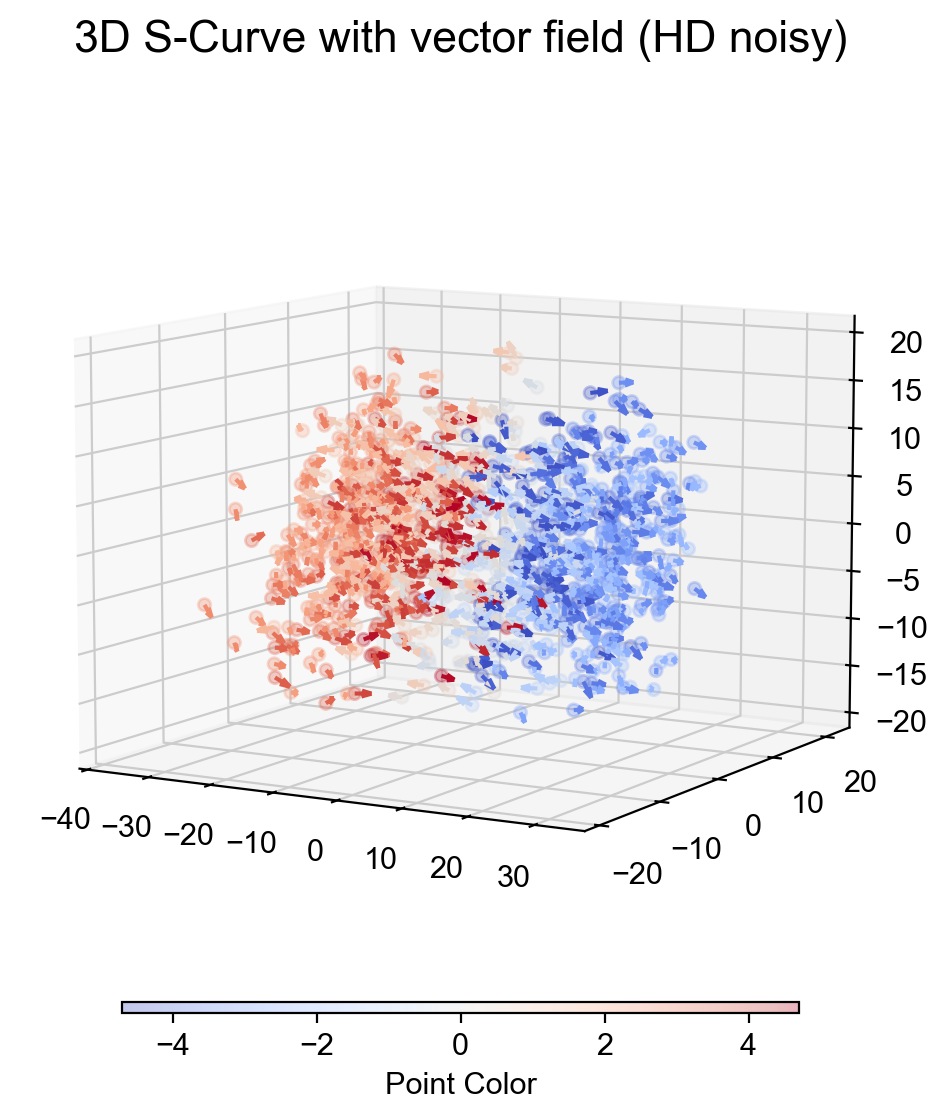

In [11]:
from sklearn.decomposition import PCA

# Perform PCA on the high-dimensional noisy position matrix
pca = PCA(n_components=3)
principal_components = pca.fit_transform(high_dim_points_noisy)  # Shape: (n_samples, 3)

# Project the high-dimensional velocity matrix using the same PCA
velocity_components = high_dim_velocity_noisy @ pca.components_.T  # Shape: (n_samples, 3)

# Visualize using the provided function
plot_3d_with_quiver(
    principal_components,
    velocity_components,
    t,
    arrow_size=2,
    title="3D S-Curve with vector field (HD noisy)",
)